# Оптимальное управление угловым движением спутника

Вариант 35. Ноутбук сделан универсальным: конечная точка задается параметрами `x1f` и `x2f` в первой кодовой ячейке. После изменения этих значений нужно выполнить `Run All`, и расчет, управление, численное моделирование и графики перестроятся автоматически.

## 1. Исходные данные и выбор конечной точки

Переменные состояния: $x_1 = \nu$, $x_2 = \dot\nu$. Значения `x1f` и `x2f` задаются в радианах и радианах в секунду.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

# Исходные данные
J = 2500.0          # кг*м^2
M_max = 45.0        # Н*м
k = M_max / J       # рад/с^2

# Начальные условия
x10_deg = -40.0
x20_deg = 25.0

x10 = np.deg2rad(x10_deg)
x20 = np.deg2rad(x20_deg)

# Конечная точка
x1f = 0.5           # рад
x2f = 0.5           # рад/с

print("Исходные данные")
print("---------------")
print(f"J = {J:.1f} кг*м^2")
print(f"M_max = {M_max:.1f} Н*м")
print(f"k = {k:.6f} рад/с^2")
print(f"x10 = {x10:.9f} рад")
print(f"x20 = {x20:.9f} рад/с")
print(f"x1f = {x1f:.9f} рад")
print(f"x2f = {x2f:.9f} рад/с")


Исходные данные
---------------
J = 2500.0 кг*м^2
M_max = 45.0 Н*м
k = 0.018000 рад/с^2
x10 = -0.698131701 рад
x20 = 0.436332313 рад/с
x1f = 0.500000000 рад
x2f = 0.500000000 рад/с


## 2. Универсальный аналитический расчет

Для системы

$$
\dot x_1 = x_2, \qquad \dot x_2 = k\mu, \qquad \mu \in \{-1,+1\},
$$

оптимальная по времени траектория строится из двух дуг с постоянными управлениями. Код ниже проверяет оба возможных порядка управления: сначала $+1$, затем $-1$, и сначала $-1$, затем $+1$. Из допустимых вариантов выбирается вариант с минимальным временем.

In [10]:
def phase_constant(k, mu, x1, x2):
    return x2**2 - 2 * k * mu * x1


def solve_bang_bang(k, x10, x20, x1f, x2f, tol=1e-10):
    if abs(x10 - x1f) <= tol and abs(x20 - x2f) <= tol:
        return {
            "mu1": 0,
            "mu2": 0,
            "C_start": phase_constant(k, 1, x10, x20),
            "C_final": phase_constant(k, 1, x1f, x2f),
            "x1_sw": x10,
            "x2_sw": x20,
            "dt1": 0.0,
            "dt2": 0.0,
            "T": 0.0,
        }

    candidates = []

    # Проверяем оба порядка управления
    for mu1 in (+1, -1):
        mu2 = -mu1

        C_start = phase_constant(k, mu1, x10, x20)
        C_final = phase_constant(k, mu2, x1f, x2f)

        # Точка пересечения фазовых кривых
        x1_sw = (C_final - C_start) / (2 * k * (mu1 - mu2))
        radicand = 2 * k * mu1 * x1_sw + C_start

        if radicand < -1e-8:
            continue

        radicand = max(0.0, radicand)
        roots = [0.0] if radicand <= tol else [np.sqrt(radicand), -np.sqrt(radicand)]

        for x2_sw in roots:
            dt1 = (x2_sw - x20) / (k * mu1)
            dt2 = (x2f - x2_sw) / (k * mu2)

            if dt1 < -1e-8 or dt2 < -1e-8:
                continue

            dt1 = max(0.0, float(dt1))
            dt2 = max(0.0, float(dt2))

            x1_sw_check = x10 + x20 * dt1 + 0.5 * k * mu1 * dt1**2
            x1f_check = x1_sw + x2_sw * dt2 + 0.5 * k * mu2 * dt2**2
            x2f_check = x2_sw + k * mu2 * dt2

            error = max(
                abs(x1_sw_check - x1_sw),
                abs(x1f_check - x1f),
                abs(x2f_check - x2f),
            )

            if error <= 1e-7:
                candidates.append({
                    "mu1": mu1,
                    "mu2": mu2,
                    "C_start": C_start,
                    "C_final": C_final,
                    "x1_sw": float(x1_sw),
                    "x2_sw": float(x2_sw),
                    "dt1": dt1,
                    "dt2": dt2,
                    "T": dt1 + dt2,
                    "error": float(error),
                })

    if not candidates:
        raise RuntimeError("Не найден допустимый двухучастковый переход для заданной конечной точки.")

    return min(candidates, key=lambda item: item["T"])


def state_on_segment(x1_start, x2_start, t_local, mu):
    x1 = x1_start + x2_start * t_local + 0.5 * k * mu * t_local**2
    x2 = x2_start + k * mu * t_local
    return x1, x2


def phase_branch(x1_grid, mu, C, sign=1):
    radicand = 2 * k * mu * x1_grid + C
    x2 = np.full_like(x1_grid, np.nan, dtype=float)
    mask = radicand >= 0
    x2[mask] = sign * np.sqrt(radicand[mask])
    return x2


In [11]:
# Аналитический расчет
solution = solve_bang_bang(k, x10, x20, x1f, x2f)

mu1 = solution["mu1"]
mu2 = solution["mu2"]
C_start = solution["C_start"]
C_final = solution["C_final"]
x1_sw = solution["x1_sw"]
x2_sw = solution["x2_sw"]
dt1 = solution["dt1"]
dt2 = solution["dt2"]
T_opt = solution["T"]

print("Аналитический расчет")
print("--------------------")
print(f"Порядок управления: mu1 = {mu1:+.0f}, mu2 = {mu2:+.0f}")
print(f"C_start = {C_start:.9f}")
print(f"C_final = {C_final:.9f}")
print(f"x1_sw = {x1_sw:.9f} рад")
print(f"x2_sw = {x2_sw:.9f} рад/с")
print(f"Delta t1 = {dt1:.6f} с")
print(f"Delta t2 = {dt2:.6f} с")
print(f"T_opt = {T_opt:.6f} с")

# Точки для построения графиков
def make_time_grid(duration, max_points=2500):
    if duration <= 0:
        return np.array([0.0])
    count = int(min(max_points, max(2, duration * 30 + 2)))
    return np.linspace(0.0, duration, count)

t1_local = make_time_grid(dt1)
x1_1, x2_1 = state_on_segment(x10, x20, t1_local, mu1)

t2_local = make_time_grid(dt2)
x1_2, x2_2 = state_on_segment(x1_sw, x2_sw, t2_local, mu2)

t_1_global = t1_local
t_2_global = dt1 + t2_local

t_all = np.concatenate([t_1_global, t_2_global[1:]])
x1_all = np.concatenate([x1_1, x1_2[1:]])
x2_all = np.concatenate([x2_1, x2_2[1:]])
mu_all = np.concatenate([
    np.full_like(t_1_global, mu1, dtype=float),
    np.full_like(t_2_global[1:], mu2, dtype=float),
])


Аналитический расчет
--------------------
Порядок управления: mu1 = -1, mu2 = +1
C_start = 0.165253146
C_final = 0.232000000
x1_sw = -0.927039637 рад
x2_sw = -0.445675412 рад/с
Delta t1 = 49.000429 с
Delta t2 = 52.537523 с
T_opt = 101.537952 с


## 3. Численное моделирование

Для проверки выполняется интегрирование методом Рунге--Кутты четвертого порядка. На каждом участке управление постоянно, поэтому последний шаг уменьшается так, чтобы точно попасть в конец участка.

In [12]:
# Численное моделирование
def rk4_step(x1, x2, mu, h):
    k1_x1 = h * x2
    k1_x2 = h * k * mu

    k2_x1 = h * (x2 + k1_x2 / 2)
    k2_x2 = h * k * mu

    k3_x1 = h * (x2 + k2_x2 / 2)
    k3_x2 = h * k * mu

    k4_x1 = h * (x2 + k3_x2)
    k4_x2 = h * k * mu

    x1_next = x1 + (k1_x1 + 2 * k2_x1 + 2 * k3_x1 + k4_x1) / 6
    x2_next = x2 + (k1_x2 + 2 * k2_x2 + 2 * k3_x2 + k4_x2) / 6

    return x1_next, x2_next


def simulate_segment(state0, t0, duration, mu, h):
    x1, x2 = state0

    if duration <= 0:
        return np.array([t0]), np.array([x1]), np.array([x2]), np.array([mu]), np.array([x1, x2])

    t_values = [t0]
    x1_values = [x1]
    x2_values = [x2]
    mu_values = [mu]

    t = t0
    t_end = t0 + duration

    while t < t_end - 1e-12:
        h_step = min(h, t_end - t)
        x1, x2 = rk4_step(x1, x2, mu, h_step)
        t += h_step

        t_values.append(t)
        x1_values.append(x1)
        x2_values.append(x2)
        mu_values.append(mu)

    return (
        np.array(t_values),
        np.array(x1_values),
        np.array(x2_values),
        np.array(mu_values),
        np.array([x1, x2]),
    )


def simulate(h=0.001):
    state0 = np.array([x10, x20], dtype=float)

    if T_opt == 0:
        return (
            np.array([0.0]),
            np.array([x10]),
            np.array([x20]),
            np.array([0.0]),
            state0,
            state0,
        )

    t_a, x1_a, x2_a, mu_a, state_sw_num = simulate_segment(state0, 0.0, dt1, mu1, h)
    t_b, x1_b, x2_b, mu_b, state_final_num = simulate_segment(state_sw_num, dt1, dt2, mu2, h)

    t_values = np.concatenate([t_a, t_b[1:]])
    x1_values = np.concatenate([x1_a, x1_b[1:]])
    x2_values = np.concatenate([x2_a, x2_b[1:]])
    mu_values = np.concatenate([mu_a, mu_b[1:]])

    return t_values, x1_values, x2_values, mu_values, state_sw_num, state_final_num


t_num, x1_num, x2_num, mu_num, state_sw_num, state_final_num = simulate(h=0.001)

print("Численное моделирование")
print("-----------------------")
print(f"x1_sw_num = {state_sw_num[0]:.9f} рад")
print(f"x2_sw_num = {state_sw_num[1]:.9f} рад/с")
print(f"t_sw_num = {dt1:.6f} с")
print(f"x1_final_num = {state_final_num[0]:.9f} рад")
print(f"x2_final_num = {state_final_num[1]:.9f} рад/с")
print(f"t_final_num = {T_opt:.6f} с")


Численное моделирование
-----------------------
x1_sw_num = -0.927039637 рад
x2_sw_num = -0.445675412 рад/с
t_sw_num = 49.000429 с
x1_final_num = 0.500000000 рад
x2_final_num = 0.500000000 рад/с
t_final_num = 101.537952 с


## 4. Фазовые диаграммы при постоянном управлении

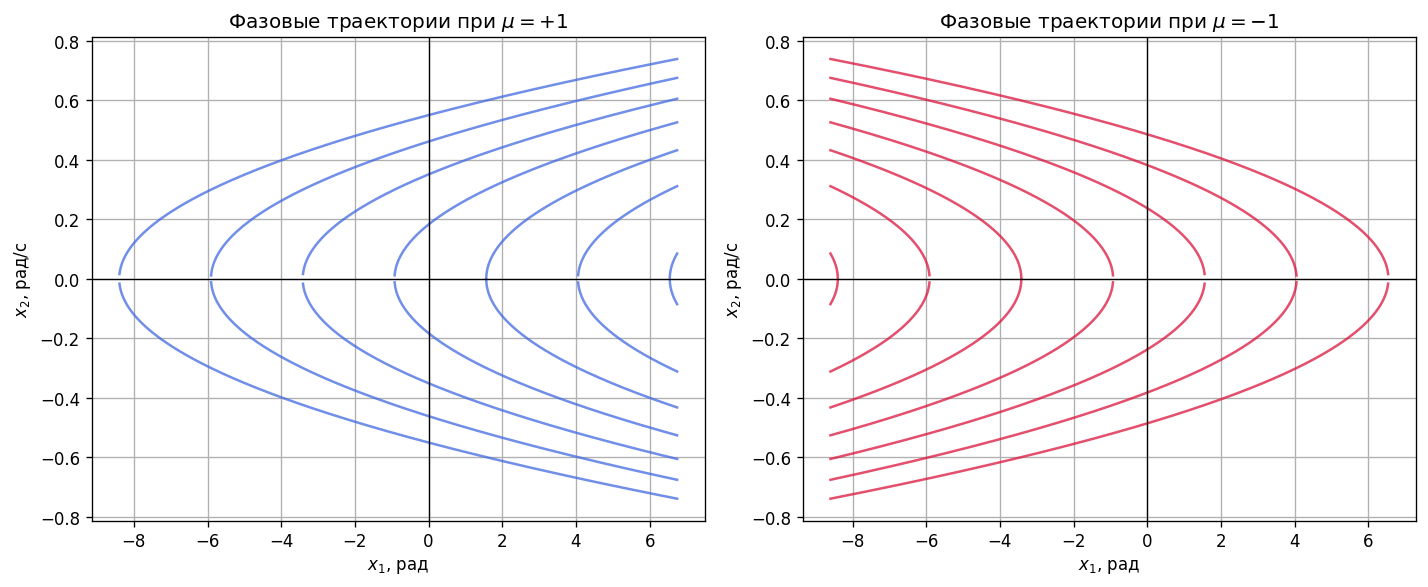

In [13]:
# Фазовые траектории при постоянном управлении
x1_plot_values = np.concatenate([
    np.atleast_1d(x1_all),
    np.array([x10, x1f, x1_sw]),
])

x_min = float(np.nanmin(x1_plot_values)) - 0.15 * max(1.0, float(np.nanmax(x1_plot_values) - np.nanmin(x1_plot_values))) - 0.5
x_max = float(np.nanmax(x1_plot_values)) + 0.15 * max(1.0, float(np.nanmax(x1_plot_values) - np.nanmin(x1_plot_values))) + 0.5
x_grid = np.linspace(x_min, x_max, 2000)
vertex_positions = np.linspace(x_min + 0.2, x_max - 0.2, 7)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for x_vertex in vertex_positions:
    C = -2 * k * x_vertex
    ax.plot(x_grid, phase_branch(x_grid, +1, C, +1), color="royalblue", alpha=0.75)
    ax.plot(x_grid, phase_branch(x_grid, +1, C, -1), color="royalblue", alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(r"Фазовые траектории при $\mu = +1$")
ax.set_xlabel(r"$x_1$, рад")
ax.set_ylabel(r"$x_2$, рад/с")

ax = axes[1]
for x_vertex in vertex_positions:
    C = 2 * k * x_vertex
    ax.plot(x_grid, phase_branch(x_grid, -1, C, +1), color="crimson", alpha=0.75)
    ax.plot(x_grid, phase_branch(x_grid, -1, C, -1), color="crimson", alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(r"Фазовые траектории при $\mu = -1$")
ax.set_xlabel(r"$x_1$, рад")
ax.set_ylabel(r"$x_2$, рад/с")

plt.tight_layout()
plt.show()


## 5. Оптимальная фазовая траектория

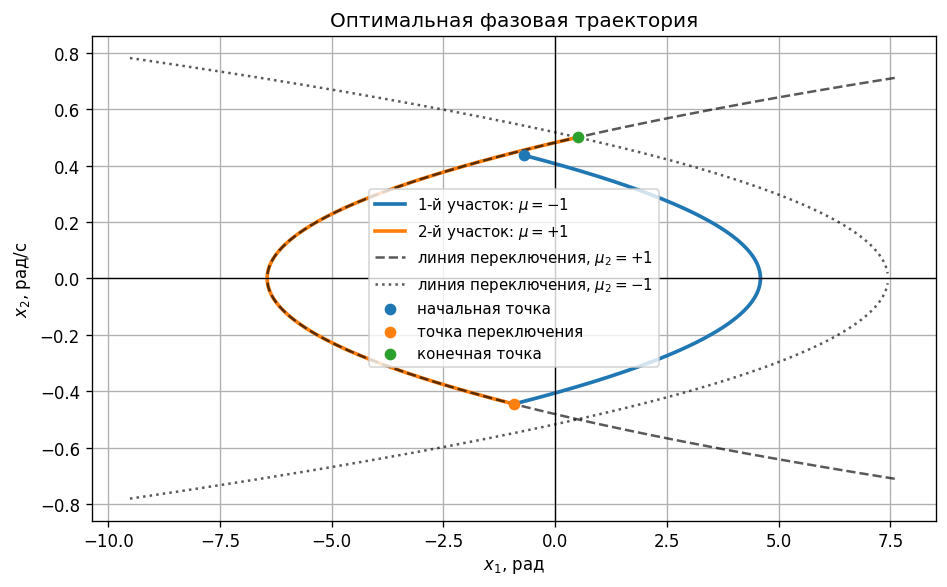

In [14]:
# Оптимальная фазовая траектория
fig, ax = plt.subplots(figsize=(8, 5))

if dt1 > 0:
    ax.plot(x1_1, x2_1, linewidth=2.2, label=fr"1-й участок: $\mu = {mu1:+.0f}$")
if dt2 > 0:
    ax.plot(x1_2, x2_2, linewidth=2.2, label=fr"2-й участок: $\mu = {mu2:+.0f}$")

C_switch_plus = phase_constant(k, +1, x1f, x2f)
C_switch_minus = phase_constant(k, -1, x1f, x2f)
x_curve_min = min(x1f, x1_sw, float(np.nanmin(x1_all))) - 0.2 * max(1.0, x_max - x_min)
x_curve_max = max(x1f, x1_sw, float(np.nanmax(x1_all))) + 0.2 * max(1.0, x_max - x_min)
x_curve = np.linspace(x_curve_min, x_curve_max, 2000)

ax.plot(x_curve, phase_branch(x_curve, +1, C_switch_plus, +1), "--", color="black", alpha=0.65, label=r"линия переключения, $\mu_2 = +1$")
ax.plot(x_curve, phase_branch(x_curve, +1, C_switch_plus, -1), "--", color="black", alpha=0.65)
ax.plot(x_curve, phase_branch(x_curve, -1, C_switch_minus, +1), ":", color="black", alpha=0.65, label=r"линия переключения, $\mu_2 = -1$")
ax.plot(x_curve, phase_branch(x_curve, -1, C_switch_minus, -1), ":", color="black", alpha=0.65)

ax.scatter(x10, x20, zorder=5, label="начальная точка")
ax.scatter(x1_sw, x2_sw, zorder=5, label="точка переключения")
ax.scatter(x1f, x2f, zorder=5, label="конечная точка")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Оптимальная фазовая траектория")
ax.set_xlabel(r"$x_1$, рад")
ax.set_ylabel(r"$x_2$, рад/с")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Переходные процессы и управление

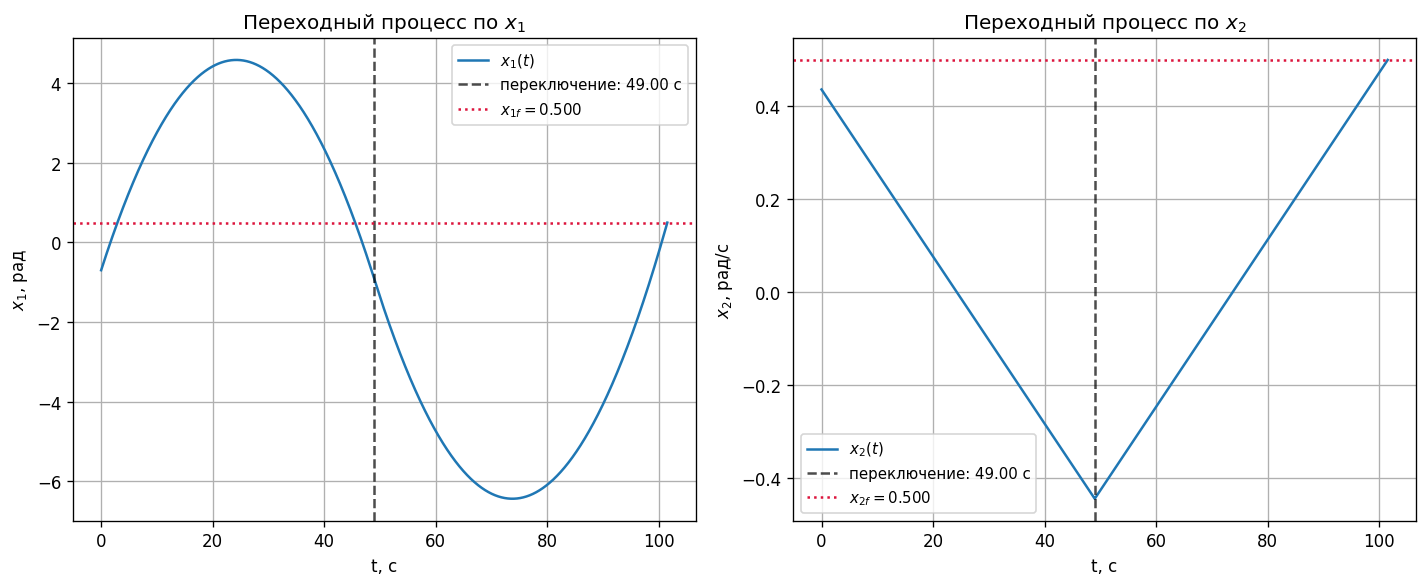

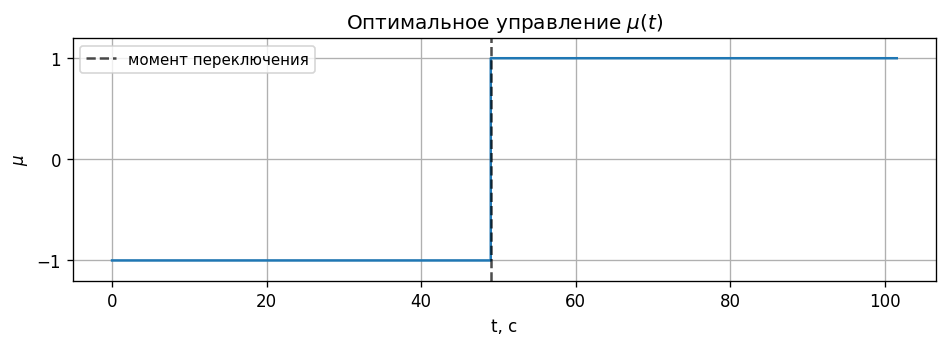

In [15]:
# Графики x1(t), x2(t) и mu(t)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t_num, x1_num, label=r"$x_1(t)$")
axes[0].axvline(dt1, linestyle="--", color="black", alpha=0.7, label=f"переключение: {dt1:.2f} с")
axes[0].axhline(x1f, linestyle=":", color="crimson", label=fr"$x_{{1f}} = {x1f:.3f}$")
axes[0].set_title(r"Переходный процесс по $x_1$")
axes[0].set_xlabel("t, с")
axes[0].set_ylabel(r"$x_1$, рад")
axes[0].legend(loc="best", fontsize=9)

axes[1].plot(t_num, x2_num, label=r"$x_2(t)$")
axes[1].axvline(dt1, linestyle="--", color="black", alpha=0.7, label=f"переключение: {dt1:.2f} с")
axes[1].axhline(x2f, linestyle=":", color="crimson", label=fr"$x_{{2f}} = {x2f:.3f}$")
axes[1].set_title(r"Переходный процесс по $x_2$")
axes[1].set_xlabel("t, с")
axes[1].set_ylabel(r"$x_2$, рад/с")
axes[1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.step(t_num, mu_num, where="post")
ax.axvline(dt1, linestyle="--", color="black", alpha=0.7, label="момент переключения")
ax.set_title(r"Оптимальное управление $\mu(t)$")
ax.set_xlabel("t, с")
ax.set_ylabel(r"$\mu$")
ax.set_yticks([-1, 0, 1])
ax.set_ylim(-1.2, 1.2)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Сравнение аналитических и численных значений

In [16]:
# Сравнение результатов
rows = [
    ("x1_sw", x1_sw, state_sw_num[0], "рад"),
    ("x2_sw", x2_sw, state_sw_num[1], "рад/с"),
    ("x1_final", x1f, state_final_num[0], "рад"),
    ("x2_final", x2f, state_final_num[1], "рад/с"),
    ("Delta t1", dt1, dt1, "с"),
    ("Delta t2", dt2, dt2, "с"),
    ("T", T_opt, T_opt, "с"),
]

print(f"{'Параметр':<12} {'Аналитически':>16} {'Численно':>16} {'Разность':>14} {'Ед.':>8}")
print("-" * 74)
for name, calc, model, unit in rows:
    diff = abs(calc - model)
    print(f"{name:<12} {calc:>16.9f} {model:>16.9f} {diff:>14.3e} {unit:>8}")


Параметр         Аналитически         Численно       Разность      Ед.
--------------------------------------------------------------------------
x1_sw            -0.927039637     -0.927039637      1.685e-11      рад
x2_sw            -0.445675412     -0.445675412      6.901e-13    рад/с
x1_final          0.500000000      0.500000000      1.175e-10      рад
x2_final          0.500000000      0.500000000      2.956e-12    рад/с
Delta t1         49.000429180     49.000429180      0.000e+00        с
Delta t2         52.537522902     52.537522902      0.000e+00        с
T               101.537952081    101.537952081      0.000e+00        с
